# 13 - Tiny Phase Network + AFinal Refinement

This notebook takes the real scanner path from `example.ipynb` cell 2 and keeps only the core experiment:

1. fit a tiny test-time phase network from odd/even SPEN lines,
2. reconstruct the corrected data with `InvA`,
3. refine that image against `AFinal @ x ~= corrected_rofft`, because `InvA` is an adjoint, not a true inverse.

The main result is the visual comparison between the exported traditional reconstruction and this strategy.

In [ ]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy.io
import torch
import torch.nn as nn

ROOT = Path("/home/data1/musong/workspace/python/spen_recons")
SPENPY_ROOT = ROOT / "spenpy"
if str(SPENPY_ROOT) not in sys.path:
    sys.path.insert(0, str(SPENPY_ROOT))

from spenpy.core import calcInvA
from spenpy.recon.spen_recon import orient_pv360_spen_image
from spenpy.utils.coil_combine import coil_combine
from spenpy.utils.tensor import mult_mat_tensor

plt.rcParams["figure.dpi"] = 120
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [ ]:
MAT_PATH = ROOT / "data/mat/20231011_lxj_SPEN_data_231011_3_1_3/slice_19.mat"
mat = scipy.io.loadmat(MAT_PATH, squeeze_me=True, struct_as_record=False)

spen_original = np.asarray(mat["spen_original"])
traditional_recon = np.asarray(mat["traditional_recon"])

rofft_np = mat["spen_original_signal_rofft"]
if rofft_np.ndim == 3:
    rofft_np = rofft_np[:, :, None, :]
rofft = torch.as_tensor(np.ascontiguousarray(rofft_np), dtype=torch.complex64, device=device)
params = mat["calc_inva_params"]


def build_matrices(args):
    args = torch.as_tensor(args, dtype=torch.float64, device=device).flatten()
    inv_a, a_final = calcInvA(args[0], args[1], int(args[2].item()), args[3], int(args[4].item()), args[5], args[6])
    return inv_a.to(torch.complex64), a_final.to(torch.complex64)


InvA, AFinal = build_matrices(params.full_args)
OddInvA, _ = build_matrices(params.odd_args)
EvenInvA, _ = build_matrices(params.even_args)

print("rofft [PE, RO, image, coil]:", tuple(rofft.shape))
print("InvA / AFinal:", tuple(InvA.shape), tuple(AFinal.shape))

rofft [PE, RO, image, coil]: (96, 96, 1, 4)
InvA / AFinal: (96, 96) (96, 96)


In [ ]:
def sync_device():
    if device.type == "cuda":
        torch.cuda.synchronize()


def timed(fn):
    sync_device()
    start = time.perf_counter()
    out = fn()
    sync_device()
    return out, time.perf_counter() - start


def to_numpy(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().resolve_conj().numpy()
    return np.asarray(value)


def orient(value):
    return np.ascontiguousarray(orient_pv360_spen_image(to_numpy(value)).copy())


def robust_abs01(value, percentile=99.5):
    image = np.abs(to_numpy(value)).astype(np.float32)
    positive = image[image > 0]
    scale = np.percentile(positive, percentile) if positive.size else 1.0
    return np.clip(image / max(float(scale), 1e-8), 0.0, 1.0)


def show(ax, value, title, cmap="gray", vmin=None, vmax=None, colorbar=False):
    im = ax.imshow(to_numpy(value), cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis("off")
    if colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


def wrap_phase(x):
    return torch.atan2(torch.sin(x), torch.cos(x))


def combine_image(x):
    return coil_combine(x[:, :, 0, :].unsqueeze(2)).squeeze()


def recon_from_rofft(y):
    return combine_image(mult_mat_tensor(InvA, y))


def apply_even_phase(y, phase):
    out = y.clone()
    out[1::2] *= torch.exp(-1j * phase[:, :, None, None]).to(torch.complex64)
    return out


def data_nrmse(x, y):
    pred = mult_mat_tensor(AFinal, x)
    return torch.linalg.vector_norm((pred - y).reshape(-1)) / torch.linalg.vector_norm(y.reshape(-1)).clamp_min(1e-12)


def residual_map(x, y):
    return torch.sqrt((mult_mat_tensor(AFinal, x) - y).abs().square().mean(dim=(2, 3)))


def per_coil_gain(source, target):
    denom = source.abs().square().sum(dim=(0, 1, 2)).clamp_min(1e-12)
    return (target * torch.conj(source)).sum(dim=(0, 1, 2)) / denom

## Tiny Test-Time Phase Network

In [ ]:
class TinyPhaseNet(nn.Module):
    def __init__(self, hidden=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, coords):
        return self.net(coords).squeeze(-1)


def normalized_coords(height, width):
    y = torch.linspace(-1.0, 1.0, height, device=device)
    x = torch.linspace(-1.0, 1.0, width, device=device)
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    return torch.stack([xx, yy], dim=-1).reshape(-1, 2)


def phase_fit_inputs(y):
    odd = mult_mat_tensor(OddInvA, y[0::2])[:, :, 0, :]
    even = mult_mat_tensor(EvenInvA, y[1::2])[:, :, 0, :]
    cross = torch.sum(even * torch.conj(odd), dim=-1)
    raw_phase = torch.angle(cross).float()

    odd_mag = torch.sqrt(torch.sum(odd.abs().square(), dim=-1))
    even_mag = torch.sqrt(torch.sum(even.abs().square(), dim=-1))
    mag_std = torch.std(even_mag - odd_mag)
    mask = (odd_mag > 2.0 * mag_std) & (even_mag > 2.0 * mag_std) & torch.isfinite(raw_phase)
    cutoff = torch.quantile(cross.abs()[mask], 0.20) if torch.any(mask) else cross.abs().new_tensor(0.0)
    mask = mask & (cross.abs() >= cutoff)

    weights = mask.float() * torch.minimum(odd_mag, even_mag).float()
    weights = weights / weights.max().clamp_min(1e-8)
    return odd, even, raw_phase, mask, weights


def fit_tiny_phase(y, steps=500, lr=3e-2, smooth_weight=2e-3):
    odd, even, raw_phase, mask, weights = phase_fit_inputs(y)
    height, width = raw_phase.shape
    coords = normalized_coords(height, width)
    model = TinyPhaseNet(hidden=8).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    history = []

    for step in range(steps + 1):
        optimizer.zero_grad(set_to_none=True)
        phase = model(coords).reshape(height, width)
        corrected_even = even * torch.exp(-1j * phase[:, :, None])
        cross = torch.sum(corrected_even * torch.conj(odd), dim=-1)
        alignment = 1.0 - torch.sum(weights * torch.real(cross) / cross.abs().clamp_min(1e-8)) / weights.sum().clamp_min(1e-8)
        smooth = wrap_phase(phase[:, 1:] - phase[:, :-1]).square().mean() + wrap_phase(phase[1:] - phase[:-1]).square().mean()
        loss = alignment + smooth_weight * smooth
        loss.backward()
        optimizer.step()

        if step % 100 == 0 or step == steps:
            history.append((step, float(alignment.detach()), float(smooth.detach())))

    phase = model(coords).reshape(height, width).detach()
    corrected_even = even * torch.exp(-1j * phase[:, :, None])
    residual_phase = torch.angle(torch.sum(corrected_even * torch.conj(odd), dim=-1)).float()
    return phase, raw_phase, residual_phase, mask, history


(phase_map, raw_phase, phase_residual, phase_mask, phase_history), phase_time = timed(lambda: fit_tiny_phase(rofft))
corrected_rofft = apply_even_phase(rofft, phase_map)
recon_raw = recon_from_rofft(rofft)
recon_tiny_inva = recon_from_rofft(corrected_rofft)

print(f"phase network time: {phase_time:.2f} s")
print(f"phase mask fraction: {phase_mask.float().mean().item():.3f}")
print(f"masked |phase| before: {raw_phase[phase_mask].abs().mean().item():.4f} rad")
print(f"masked |phase| after : {phase_residual[phase_mask].abs().mean().item():.4f} rad")

phase network time: 5.37 s
phase mask fraction: 0.280
masked |phase| before: 1.0848 rad
masked |phase| after : 0.2240 rad


## AFinal Refinement

In [ ]:
def refine_with_afinal(y_corrected, steps=160, lr=5e-2, tv_weight=2e-4, close_weight=5e-1):
    y_scale = y_corrected.abs().square().mean().sqrt().clamp_min(1e-8)
    y = y_corrected / y_scale

    with torch.no_grad():
        x0_raw = mult_mat_tensor(InvA, y)
        gain = per_coil_gain(mult_mat_tensor(AFinal, x0_raw), y).view(1, 1, 1, -1)
        x0 = (gain * x0_raw).detach()

    param = torch.stack([x0.real, x0.imag], dim=0).requires_grad_(True)
    optimizer = torch.optim.Adam([param], lr=lr)
    y_energy = y.abs().square().mean().clamp_min(1e-12)
    x0_energy = x0.abs().square().mean().clamp_min(1e-12)
    history = []

    def total_variation(x):
        mag = x.abs()
        return (mag[1:] - mag[:-1]).abs().mean() + (mag[:, 1:] - mag[:, :-1]).abs().mean()

    for step in range(steps + 1):
        x = torch.complex(param[0], param[1])
        data_loss = (mult_mat_tensor(AFinal, x) - y).abs().square().mean() / y_energy
        tv_loss = total_variation(x) / x.abs().mean().clamp_min(1e-8)
        close_loss = (x - x0).abs().square().mean() / x0_energy
        loss = data_loss + tv_weight * tv_loss + close_weight * close_loss

        if step % 20 == 0 or step == steps:
            history.append((step, float(data_loss.detach()), float(close_loss.detach()), float(data_nrmse(x.detach(), y))))
        if step == steps:
            break

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    return torch.complex(param[0], param[1]).detach(), x0, y, y_scale.detach(), history


(x_opt, x_seed, y_norm, y_scale, opt_history), opt_time = timed(lambda: refine_with_afinal(corrected_rofft))
seed_image = combine_image(x_seed)
opt_image = combine_image(x_opt)
seed_residual = residual_map(x_seed, y_norm)
opt_residual = residual_map(x_opt, y_norm)

seed_nrmse = data_nrmse(x_seed, y_norm)
opt_nrmse = data_nrmse(x_opt, y_norm)
print(f"AFinal refine time: {opt_time:.2f} s")
print(f"signal RMS scale removed: {y_scale.item():.4e}")
print(f"AFinal data NRMSE, seed: {seed_nrmse.item():.5f}")
print(f"AFinal data NRMSE, opt : {opt_nrmse.item():.5f}")
print(f"residual reduction      : {(1.0 - opt_nrmse / seed_nrmse).item() * 100:.1f}%")

AFinal refine time: 0.78 s
signal RMS scale removed: 2.2981e+07
AFinal data NRMSE, seed: 0.12205
AFinal data NRMSE, opt : 0.07675
residual reduction      : 37.1%


## Main Result

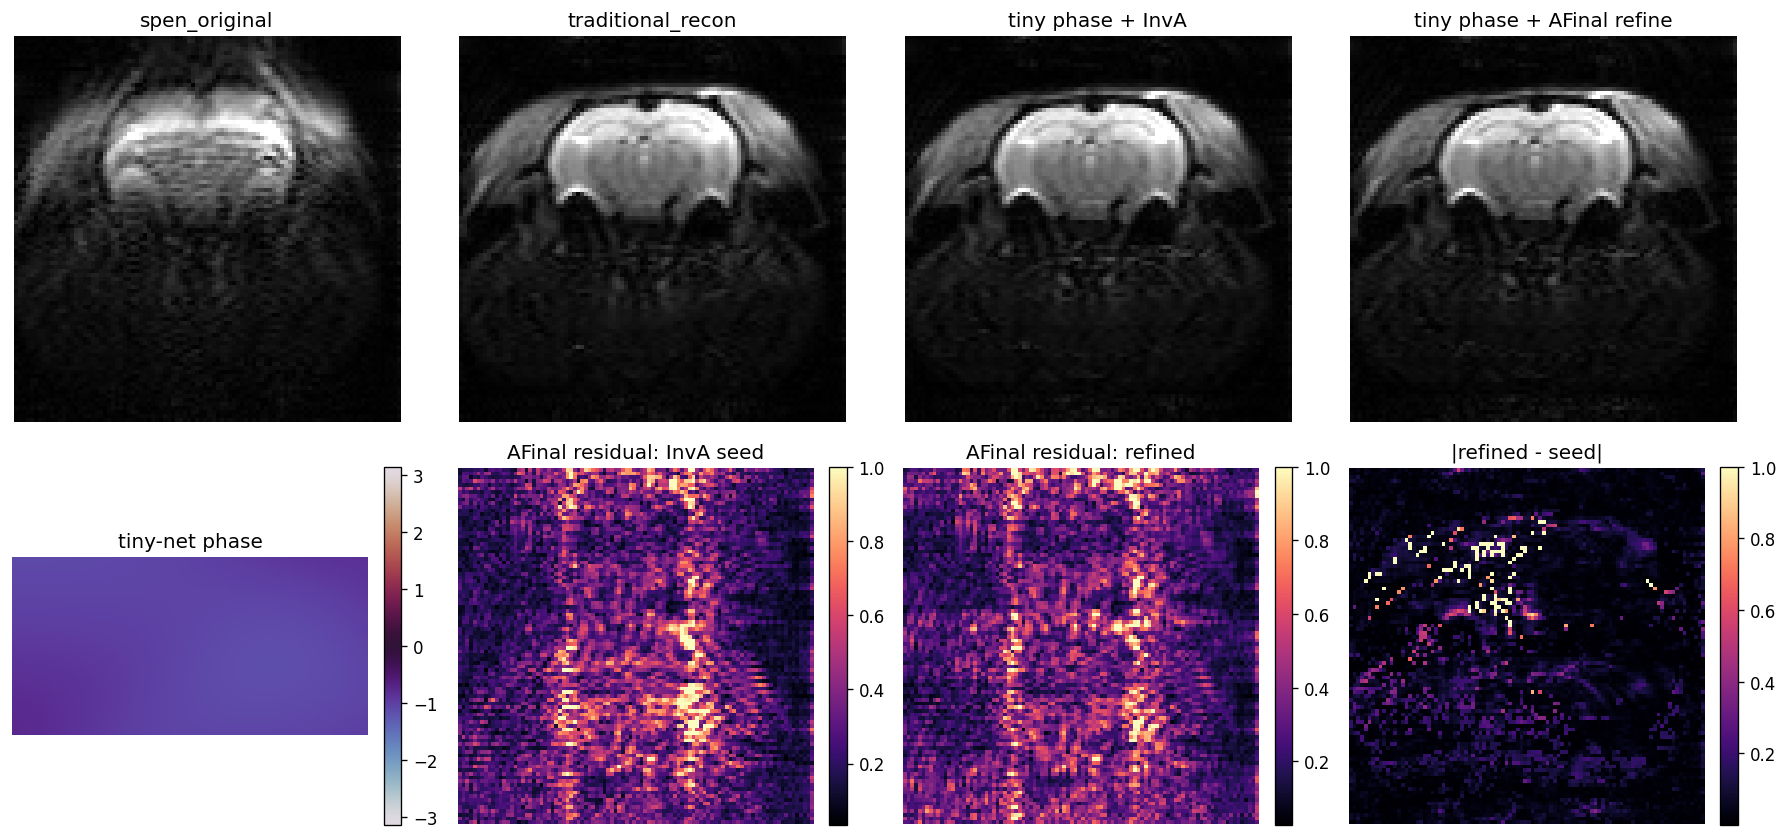

In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(15, 7.2))

show(ax[0, 0], robust_abs01(spen_original), "spen_original")
show(ax[0, 1], robust_abs01(traditional_recon), "traditional_recon")
show(ax[0, 2], robust_abs01(orient(recon_tiny_inva)), "tiny phase + InvA")
show(ax[0, 3], robust_abs01(orient(opt_image)), "tiny phase + AFinal refine")

show(ax[1, 0], orient(wrap_phase(phase_map)), "tiny-net phase", cmap="twilight", vmin=-np.pi, vmax=np.pi, colorbar=True)
show(ax[1, 1], robust_abs01(orient(seed_residual), 99.0), "AFinal residual: InvA seed", cmap="magma", colorbar=True)
show(ax[1, 2], robust_abs01(orient(opt_residual), 99.0), "AFinal residual: refined", cmap="magma", colorbar=True)
show(ax[1, 3], robust_abs01(orient(opt_image - seed_image), 99.0), "|refined - seed|", cmap="magma", colorbar=True)

plt.tight_layout()

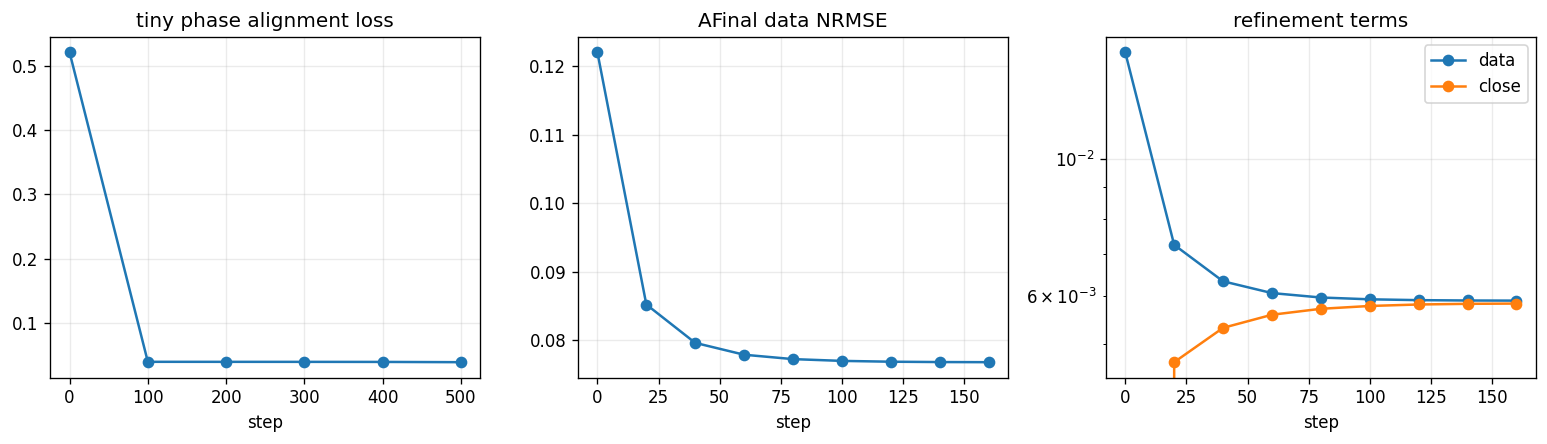

In [ ]:
steps = [row[0] for row in opt_history]
data_values = [row[1] for row in opt_history]
close_values = [row[2] for row in opt_history]
nrmse_values = [row[3] for row in opt_history]
phase_steps = [row[0] for row in phase_history]
phase_alignment = [row[1] for row in phase_history]

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].plot(phase_steps, phase_alignment, marker="o")
ax[0].set_title("tiny phase alignment loss")
ax[0].set_xlabel("step")
ax[0].grid(True, alpha=0.25)

ax[1].plot(steps, nrmse_values, marker="o")
ax[1].set_title("AFinal data NRMSE")
ax[1].set_xlabel("step")
ax[1].grid(True, alpha=0.25)

ax[2].plot(steps, data_values, marker="o", label="data")
ax[2].plot(steps, close_values, marker="o", label="close")
ax[2].set_yscale("log")
ax[2].set_title("refinement terms")
ax[2].set_xlabel("step")
ax[2].legend()
ax[2].grid(True, alpha=0.25)
plt.tight_layout()

In [ ]:
M = InvA @ AFinal
I = torch.eye(M.shape[0], dtype=M.dtype, device=device)
identity_error = torch.linalg.vector_norm(M - I) / torch.linalg.vector_norm(I)
print(f"||InvA @ AFinal - I|| / ||I|| = {identity_error.item():.4f}")
print("This is why the AFinal step refines the InvA image instead of treating InvA as exact.")

||InvA @ AFinal - I|| / ||I|| = 0.9619
This is why the AFinal step refines the InvA image instead of treating InvA as exact.
